# IMG_01 - Image Audit

## TFM - Skin Lesion Classification (ISIC 2024 / SLICE-3D)

### Objective

The purpose of this notebook is to perform a complete audit of the image dataset before any preprocessing or model development.

The metadata audit has already been completed in EDA_01.ipynb. However, image quality, image availability and image characteristics have not yet been validated.

This notebook aims to answer the following questions:

1. How many image files exist physically?
2. Do image files match metadata records?
3. Are there missing images?
4. Are there corrupted images?
5. What image formats are present?
6. What image resolutions exist?
7. What is the width and height distribution?
8. What disk space does the dataset occupy?
9. What resize strategy should be adopted?
10. Are there potential issues that could affect model training?

The results obtained in this notebook will guide all subsequent preprocessing and deep learning decisions.

# Data Loading

In [5]:
# import standard libraries

import os
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

# Project utilities
from skin_lesion_ai.utils.data_utils import load_yaml_config, path, load_raw_metadata

from skin_lesion_ai.visualisation.eda_plots import (
    set_eda_style,
    clean_axis_labels,
)

# Set the EDA style
set_eda_style()

## Load Metadata

In [6]:
# Load raw metadata

df1, df2, df3 = load_raw_metadata()

print("df1 - ground_truth:", df1.shape)
print("df2 - supplement:", df2.shape)
print("df3 - metadata:", df3.shape)

D:\Workspace\research\ub_master_thesis\my-image-classifier\src\skin_lesion_ai\utils\data_utils.py:44: DtypeWarning: Columns (0: iddx_5) have mixed types. Specify dtype option on import or set low_memory=False.
  supplement = pd.read_csv(path(raw["supplement_csv"]))


df1 - ground_truth: (401059, 2)
df2 - supplement: (401059, 13)
df3 - metadata: (401059, 42)


## Image Directory Configuration

In [7]:
# Check current working directory and path to images

config = load_yaml_config(path("configs/data_config.yaml"))

IMAGE_DIR = path(config["paths"]["raw"]["images"])

# repo_root = get_project_root()

# IMAGE_DIR = (
#     repo_root / "data" / "raw" / "images"
# )

# IMAGE_DIR = paths["raw_images"]

print("\nIMAGE_DIR: ", IMAGE_DIR)
print(IMAGE_DIR.exists())

assert IMAGE_DIR.exists()


IMAGE_DIR:  D:\Workspace\research\ub_master_thesis\my-image-classifier\data\raw\images
True


# Dataset Integrity Audit

## Physical Image Count

Count all image files available in the dataset directory.

In [8]:
# List all image files in the directory

image_files = sorted(list(IMAGE_DIR.glob("*.jpg")))

print(len(image_files))

401059


## Metadata vs Physical Files Validation

In [9]:
# Check for duplicates in metadata and images

metadata_ids = set(df1["isic_id"])

image_ids = {img.stem for img in image_files}

print("Metadata:", len(metadata_ids))
print("Images:", len(image_ids))

Metadata: 401059
Images: 401059


In [10]:
# Find missing images in the metadata

missing_images = metadata_ids - image_ids

len(missing_images)

0

In [11]:
# Find extra images not in metadata

extra_images = image_ids - metadata_ids

len(extra_images)

0

The metadata repository and the physical image repository contain exactly the same number of observations.

No missing or orphan image files were detected, confirming complete consistency between metadata and image storage.

## File Extensions Audit

In [12]:
# Check file extensions of images

extensions = {}

for file in image_files:
    ext = file.suffix.lower()
    extensions[ext] = extensions.get(ext, 0) + 1

pd.Series(extensions)

.jpg    401059
dtype: int64

There are no multiple image formats or extensions, only .jpg.

# Image Quality Audit

## Image Color Mode Audit

Deep learning models expect a fixed number of input channels.

Therefore, it is important to verify whether all images share the same color representation format.

Datasets containing a mixture of RGB, RGBA, grayscale or other color modes would require additional preprocessing to standardize the number of channels before model training.

This section evaluates the distribution of image color modes across the complete dataset.

In [13]:
# Analyze image modes (color formats)

image_modes = {}

for img_path in tqdm(image_files):
    try:
        with Image.open(img_path) as img:
            mode = img.mode

            image_modes[mode] = image_modes.get(mode, 0) + 1

    except Exception:
        pass

mode_df = pd.Series(image_modes).sort_values(ascending=False).rename("count")

mode_df

  0%|          | 0/401059 [00:00<?, ?it/s]

RGB    401059
Name: count, dtype: int64

In [14]:
# percentages of each mode

mode_pct = mode_df / mode_df.sum() * 100

mode_pct.round(4)

RGB    100.0
Name: count, dtype: float64

All images were stored using the RGB color mode.

This guarantees a homogeneous three-channel representation across the entire dataset and eliminates the need for channel standardization during preprocessing.

## Corrupted Images Audit

In [15]:
# Check for corrupted images

corrupted_files = []

for img_path in tqdm(image_files):
    try:
        with Image.open(img_path) as img:
            img.verify()

    except Exception:
        corrupted_files.append(img_path.name)

  0%|          | 0/401059 [00:00<?, ?it/s]

In [16]:
# Count corrupted images

len(corrupted_files)

0

No corrupted image files were identified.

Consequently, no image-repair or image-removal procedures are required prior to preprocessing.

# Image Resolution Audit

In [17]:
# Analyze image resolutions

# sample_size = min(20000, len(image_files))
# sample_files = np.random.choice(image_files, sample_size, replace=False)

image_stats = []
failed_images = []

for img_path in tqdm(image_files):
    try:
        with Image.open(img_path) as img:
            width, height = img.size

            image_stats.append(
                {
                    "image_id": img_path.stem,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                }
            )

    except Exception as e:
        failed_images.append(
            {
                "image_id": img_path.stem,
                "image_path": str(img_path),
                "error": str(e),
            }
        )

resolution_df = pd.DataFrame(image_stats)

failed_df = pd.DataFrame(failed_images)

print("Processed images:", len(resolution_df))
print("Failed images:", len(failed_df))

  0%|          | 0/401059 [00:00<?, ?it/s]

Processed images: 401059
Failed images: 0


## Resolution Statistics

In [50]:
# Describe the resolution statistics

resolution_df.describe()

,width,height,aspect_ratio
count,401059.000000,401059.000000,401059.0
mean,133.245316,133.245316,1.0
std,18.271392,18.271392,0.0
min,41.000000,41.000000,1.0
25%,121.000000,121.000000,1.0
50%,131.000000,131.000000,1.0
75%,143.000000,143.000000,1.0
max,269.000000,269.000000,1.0


Image dimensions are highly concentrated around 131–133 pixels.

The relatively small standard deviation (18.27 pixels) indicates a largely standardized acquisition process, although a limited number of observations exhibit substantially smaller or larger resolutions.

In [51]:
# Describe the failed images

if not failed_df.empty:
    failed_df.describe()

failed_df.head()

""


There are not failed_df images, which means that all images have the correct format and extension.

## Resolution Distribution

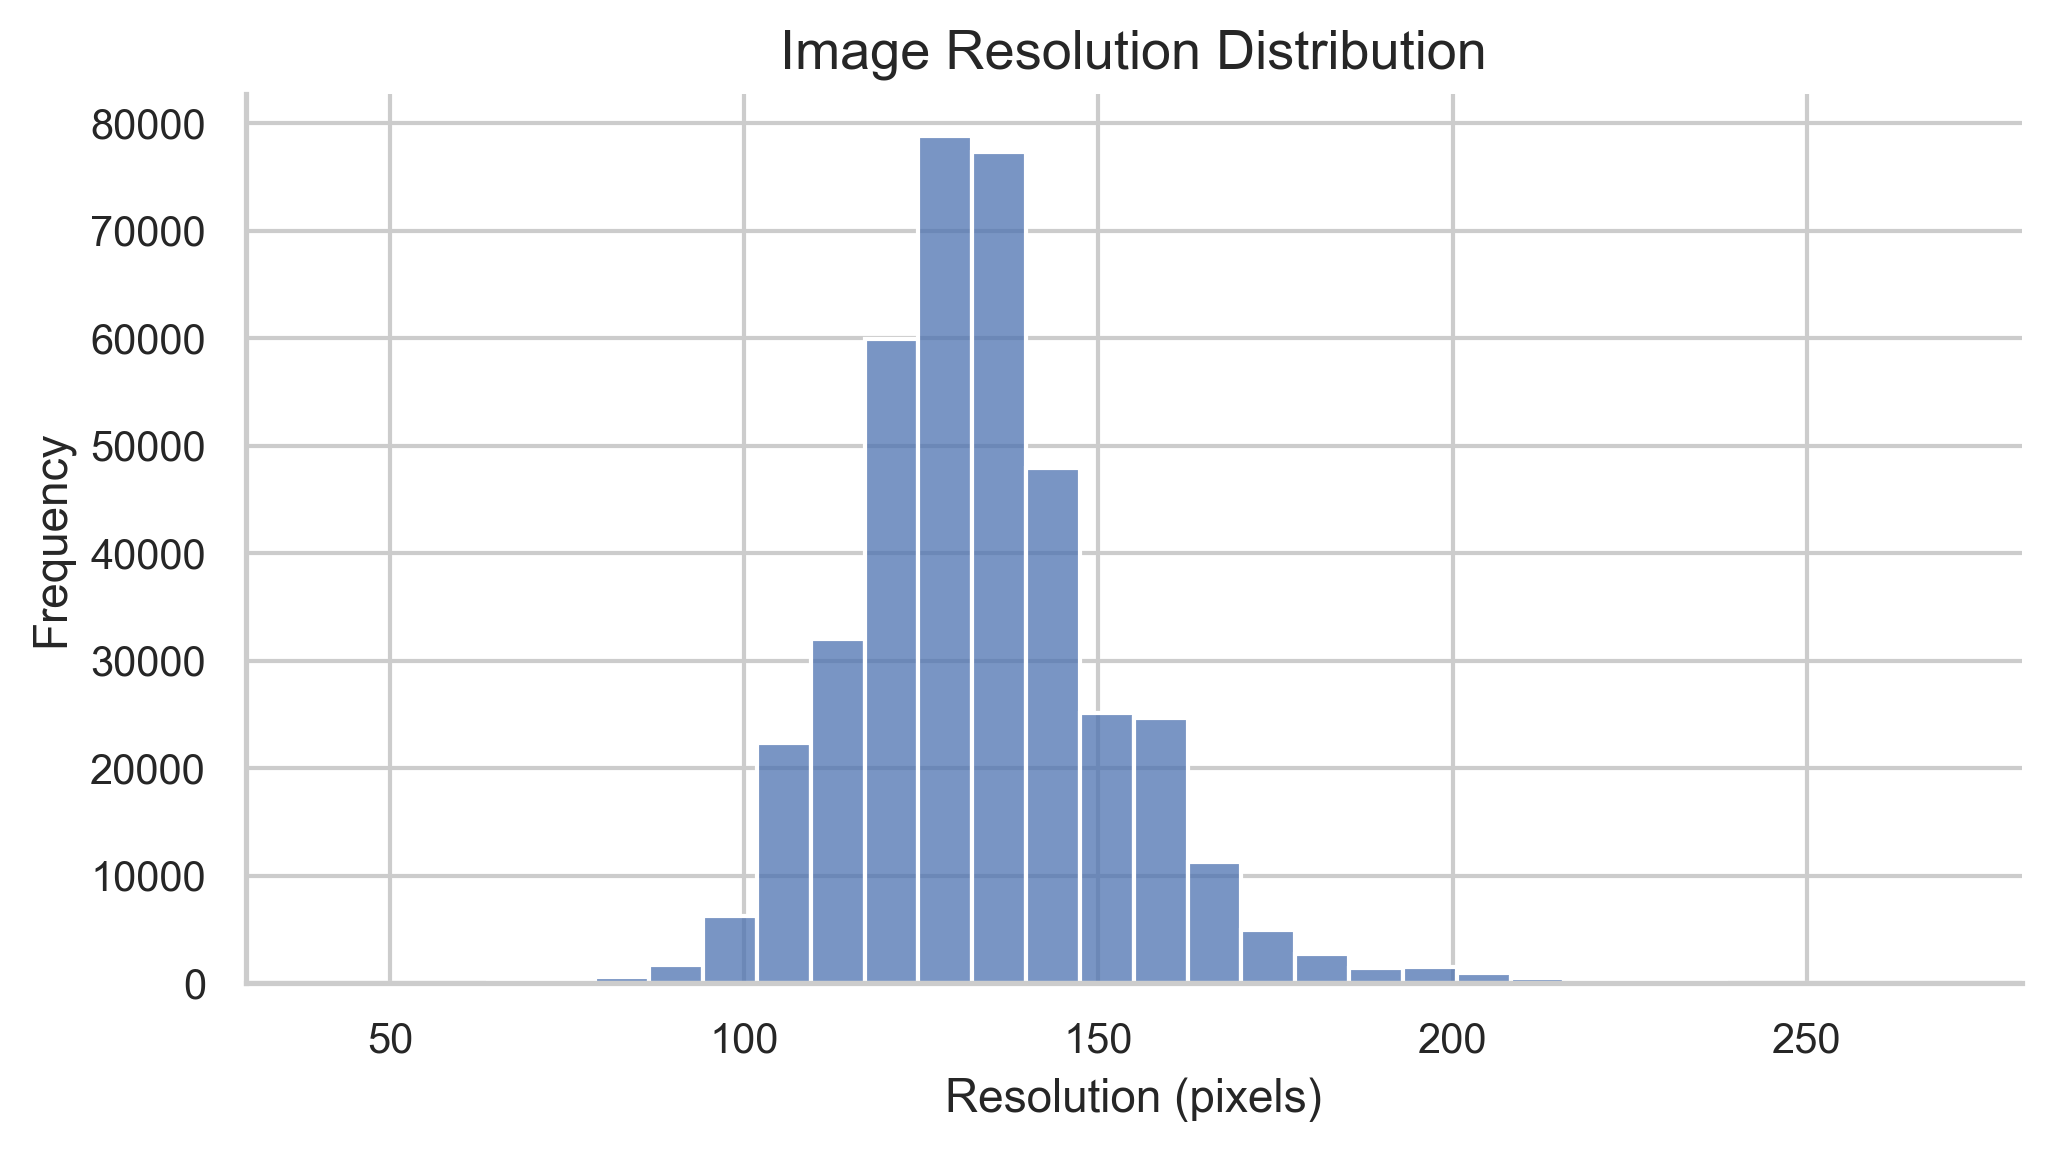

In [52]:
# Plot histograms of width and height

fig, ax = plt.subplots(figsize=(7, 4))

sns.histplot(
    resolution_df["width"],
    bins=30,
    ax=ax,
)

clean_axis_labels(
    ax,
    xlabel="Resolution (pixels)",
    ylabel="Frequency",
    title="Image Resolution Distribution",
)

plt.tight_layout()
plt.show()

The resolution distribution exhibits a clear unimodal shape centered around approximately 130 pixels.

Most observations are concentrated between 120 and 150 pixels, suggesting a highly consistent image acquisition protocol.

## Resolution Outlier Analysis

The objective of this section is to identify unusually small or unusually large images that may influence downstream preprocessing decisions.

Outliers are evaluated using percentile-based statistics, frequency distributions and visual inspection.

Because all images are square, width can be used as a proxy for image resolution.

In [53]:
# Describe the resolution statistics with custom percentiles

resolution_df.describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.90,
        0.95,
        0.99,
    ]
)

,width,height,aspect_ratio
count,401059.000000,401059.000000,401059.0
mean,133.245316,133.245316,1.0
std,18.271392,18.271392,0.0
min,41.000000,41.000000,1.0
1%,97.000000,97.000000,1.0
5%,107.000000,107.000000,1.0
10%,111.000000,111.000000,1.0
90%,157.000000,157.000000,1.0
95%,163.000000,163.000000,1.0
99%,189.000000,189.000000,1.0


Ninety-eight percent of all images are contained within the interval defined by the 1st and 99th percentiles (97–189 pixels).

Therefore, extremely small or extremely large images represent a very small fraction of the dataset.

In [54]:
# widht  = heihgt So, we can just analyze the width distribution as a proxy for resolution

size_distribution = resolution_df["width"].value_counts().sort_index()

size_distribution.head(10)

width
41     1
45     2
47     2
49     4
51     5
53     6
55    11
57    11
59     8
61    13
Name: count, dtype: int64

In [55]:
# Analyze the tail of the distribution to find rare resolutions

size_distribution.tail(10)

width
245    13
247    10
249     9
251     5
253     7
255     1
257     3
259     5
261     1
269     1
Name: count, dtype: int64

In [56]:
# Describe the size distribution

size_distribution.describe()

count      111.000000
mean      3613.144144
std       6040.352810
min          1.000000
25%         23.500000
50%        333.000000
75%       4763.000000
max      21049.000000
Name: count, dtype: float64

A total of 111 distinct image resolutions were identified across the dataset.

The frequency distribution is highly concentrated around a small set of central resolutions, while many extreme resolutions occur only a limited number of times.

This pattern suggests that image acquisition followed a largely standardized protocol, with only a small number of uncommon image sizes present in the dataset.

## Statistical Outliers (IQR Method)

The IQR rule is used as an exploratory technique to identify observations located far from the central distribution.

These observations are not automatically considered candidates for removal.

In [57]:
# Calculate IQR and identify outliers in width

Q1 = resolution_df["width"].quantile(0.25)
Q3 = resolution_df["width"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

88.0
176.0


In [58]:
# Identify outliers based on width

resolution_outliers = resolution_df[
    (resolution_df["width"] < lower_bound) | (resolution_df["width"] > upper_bound)
]

resolution_outliers.shape

(9876, 4)

In [59]:
# Display outliers

resolution_outliers.head(20)

,image_id,width,height,aspect_ratio
71,ISIC_0073877,87,87,1.0
171,ISIC_0077654,213,213,1.0
266,ISIC_0079672,177,177,1.0
305,ISIC_0080709,79,79,1.0
328,ISIC_0081287,177,177,1.0
356,ISIC_0082027,181,181,1.0
415,ISIC_0083501,193,193,1.0
430,ISIC_0083785,191,191,1.0
464,ISIC_0084664,199,199,1.0
522,ISIC_0085892,177,177,1.0


In [60]:
# Summarize outliers

print(f"Outliers: {len(resolution_outliers):,}")

print(f"Percentage: {len(resolution_outliers) / len(resolution_df) * 100:.3f}%")

Outliers: 9,876
Percentage: 2.462%


The IQR method identifies 9,876 observations (2.46%) as statistical outliers.

However, these observations are not necessarily problematic images. The IQR criterion is used here as an exploratory tool rather than as a direct exclusion rule.

## Percentile-Based Candidate Thresholds

In addition to the IQR approach, lower percentiles can be used to identify images with exceptionally low spatial resolution.

This analysis quantifies the number of images that fall below the 1st and 5th percentiles of the resolution distribution.

These observations are considered potential candidates for visual inspection, but not for automatic exclusion.

In [61]:
# Check how many images have width less than or equal to the 1 % percentile

resolution_df[resolution_df["width"] <= resolution_df["width"].quantile(0.01)].shape

(4695, 4)

Images located below the 1st percentile represent approximately 1.17% of the dataset (4,695 images).

Although these observations correspond to the lowest-resolution images available, their proportion remains small and does not justify automatic exclusion without visual inspection.

In [62]:
# Check how many images have width less than or equal to the 5 % percentile

resolution_df[resolution_df["width"] <= resolution_df["width"].quantile(0.05)].shape

(23579, 4)

Images below the 5th percentile account for approximately 5.88% of the dataset (23,579 images).

Given the relatively large number of observations involved, excluding all images below this threshold would result in a substantial loss of data and therefore requires additional justification.

## Threshold Analysis

Several candidate resolution thresholds are evaluated to quantify how many observations would be affected by a potential exclusion strategy.

The objective is not to remove images automatically, but rather to understand the proportion of the dataset represented by low-resolution observations.

In [63]:
# Check how many images are below certain width thresholds

candidate_thresholds = [
    40,
    50,
    60,
    70,
    80,
    90,
    100,
    120,
    130,
    140,
    150,
    160,
    170,
    180,
    190,
    200,
]

threshold_summary = []

for threshold in candidate_thresholds:
    n_images = (resolution_df["width"] < threshold).sum()

    pct = n_images / len(resolution_df) * 100

    # print(f"< {threshold}px : {n_images:,} ({pct:.3f}%)")

    threshold_summary.append(
        {
            "threshold": threshold,
            "n_images": n_images,
            "percentage": pct,
        }
    )

threshold_df = pd.DataFrame(threshold_summary)

threshold_df

,threshold,n_images,percentage
0,40,0,0.000000
1,50,9,0.002244
2,60,50,0.012467
3,70,191,0.047624
4,80,572,0.142622
5,90,1671,0.416647
6,100,6416,1.599765
7,120,90696,22.614129
8,130,181173,45.173653
9,140,279382,69.661072


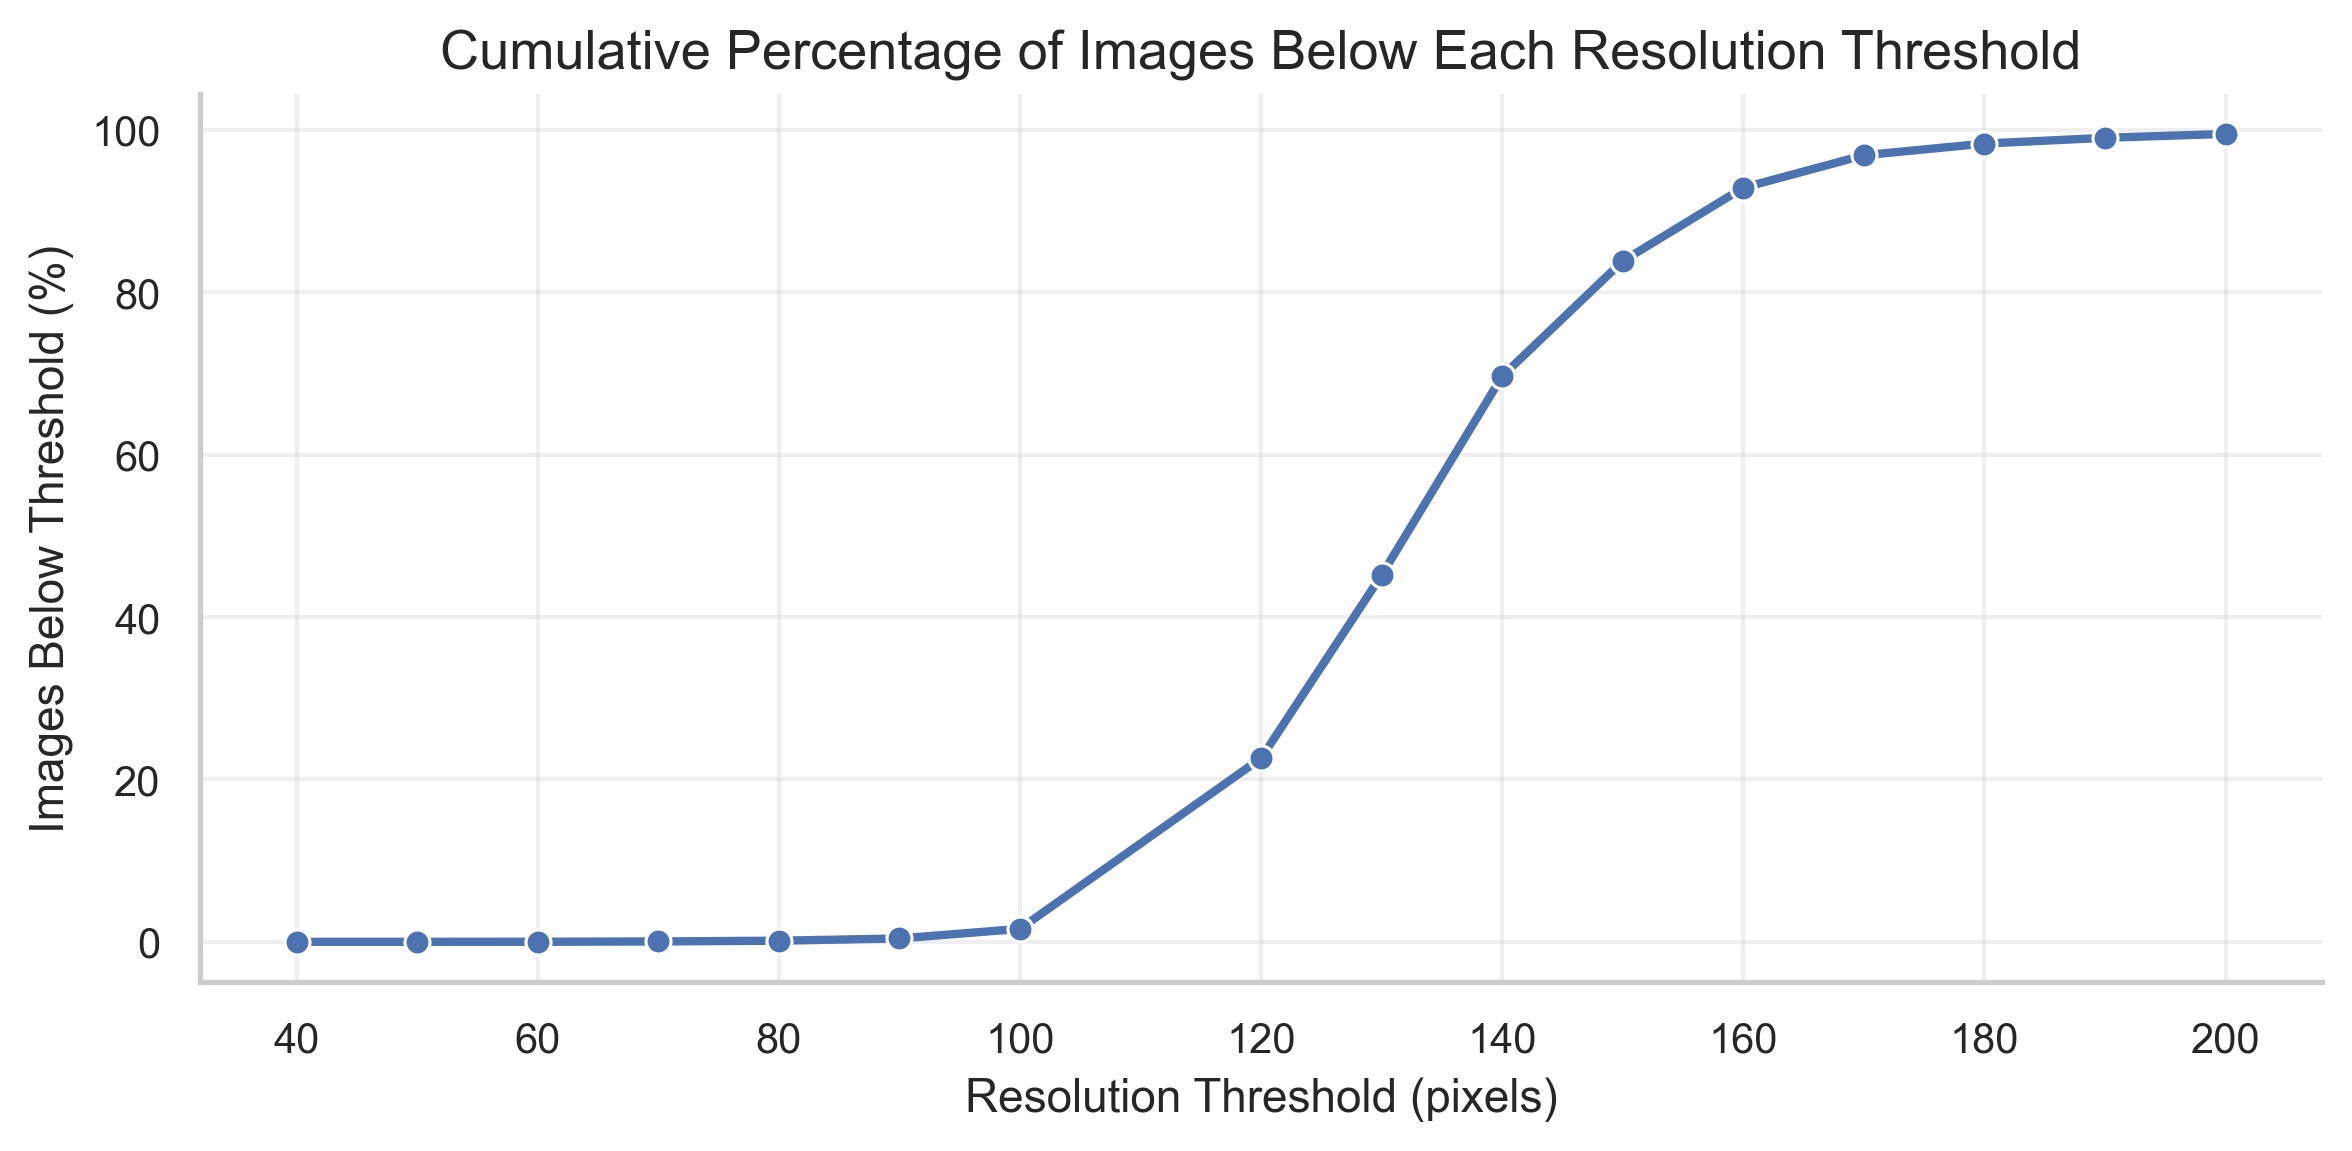

In [64]:
# Plot cumulative percentage of images below each resolution threshold

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(
    data=threshold_df,
    x="threshold",
    y="percentage",
    marker="o",
    linewidth=2,
    ax=ax,
)

clean_axis_labels(
    ax,
    xlabel="Resolution Threshold (pixels)",
    ylabel="Images Below Threshold (%)",
    title="Cumulative Percentage of Images Below Each Resolution Threshold",
)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

 * Images below 60 pixels are extremely rare, representing only 0.012% of the dataset.

Any exclusion strategy based on this threshold would have negligible impact on the overall sample size.

* Images below 80 pixels represent less than 0.15% of the dataset, indicating that extremely low-resolution observations are rare.

This threshold could be considered for further investigation without materially affecting dataset size.

* Images below 100 pixels account for approximately 1.6% of all observations.

Although still relatively uncommon, this group is large enough to warrant visual inspection before considering exclusion.

* However, the proportion of affected observations increases rapidly beyond 100 pixels, reaching approximately 22.6% below 120 pixels and 45.2% below 130 pixels.

These results suggest that aggressive exclusion thresholds would remove a substantial fraction of the dataset and therefore require strong justification.

# Visual Inspection

Statistical outliers do not necessarily correspond to low-quality images.

Therefore, the smallest images in the dataset are visually inspected before considering any exclusion criteria.

The objective is to determine whether lesion information remains visible after extreme reductions in spatial resolution.

## Random Image Visualization

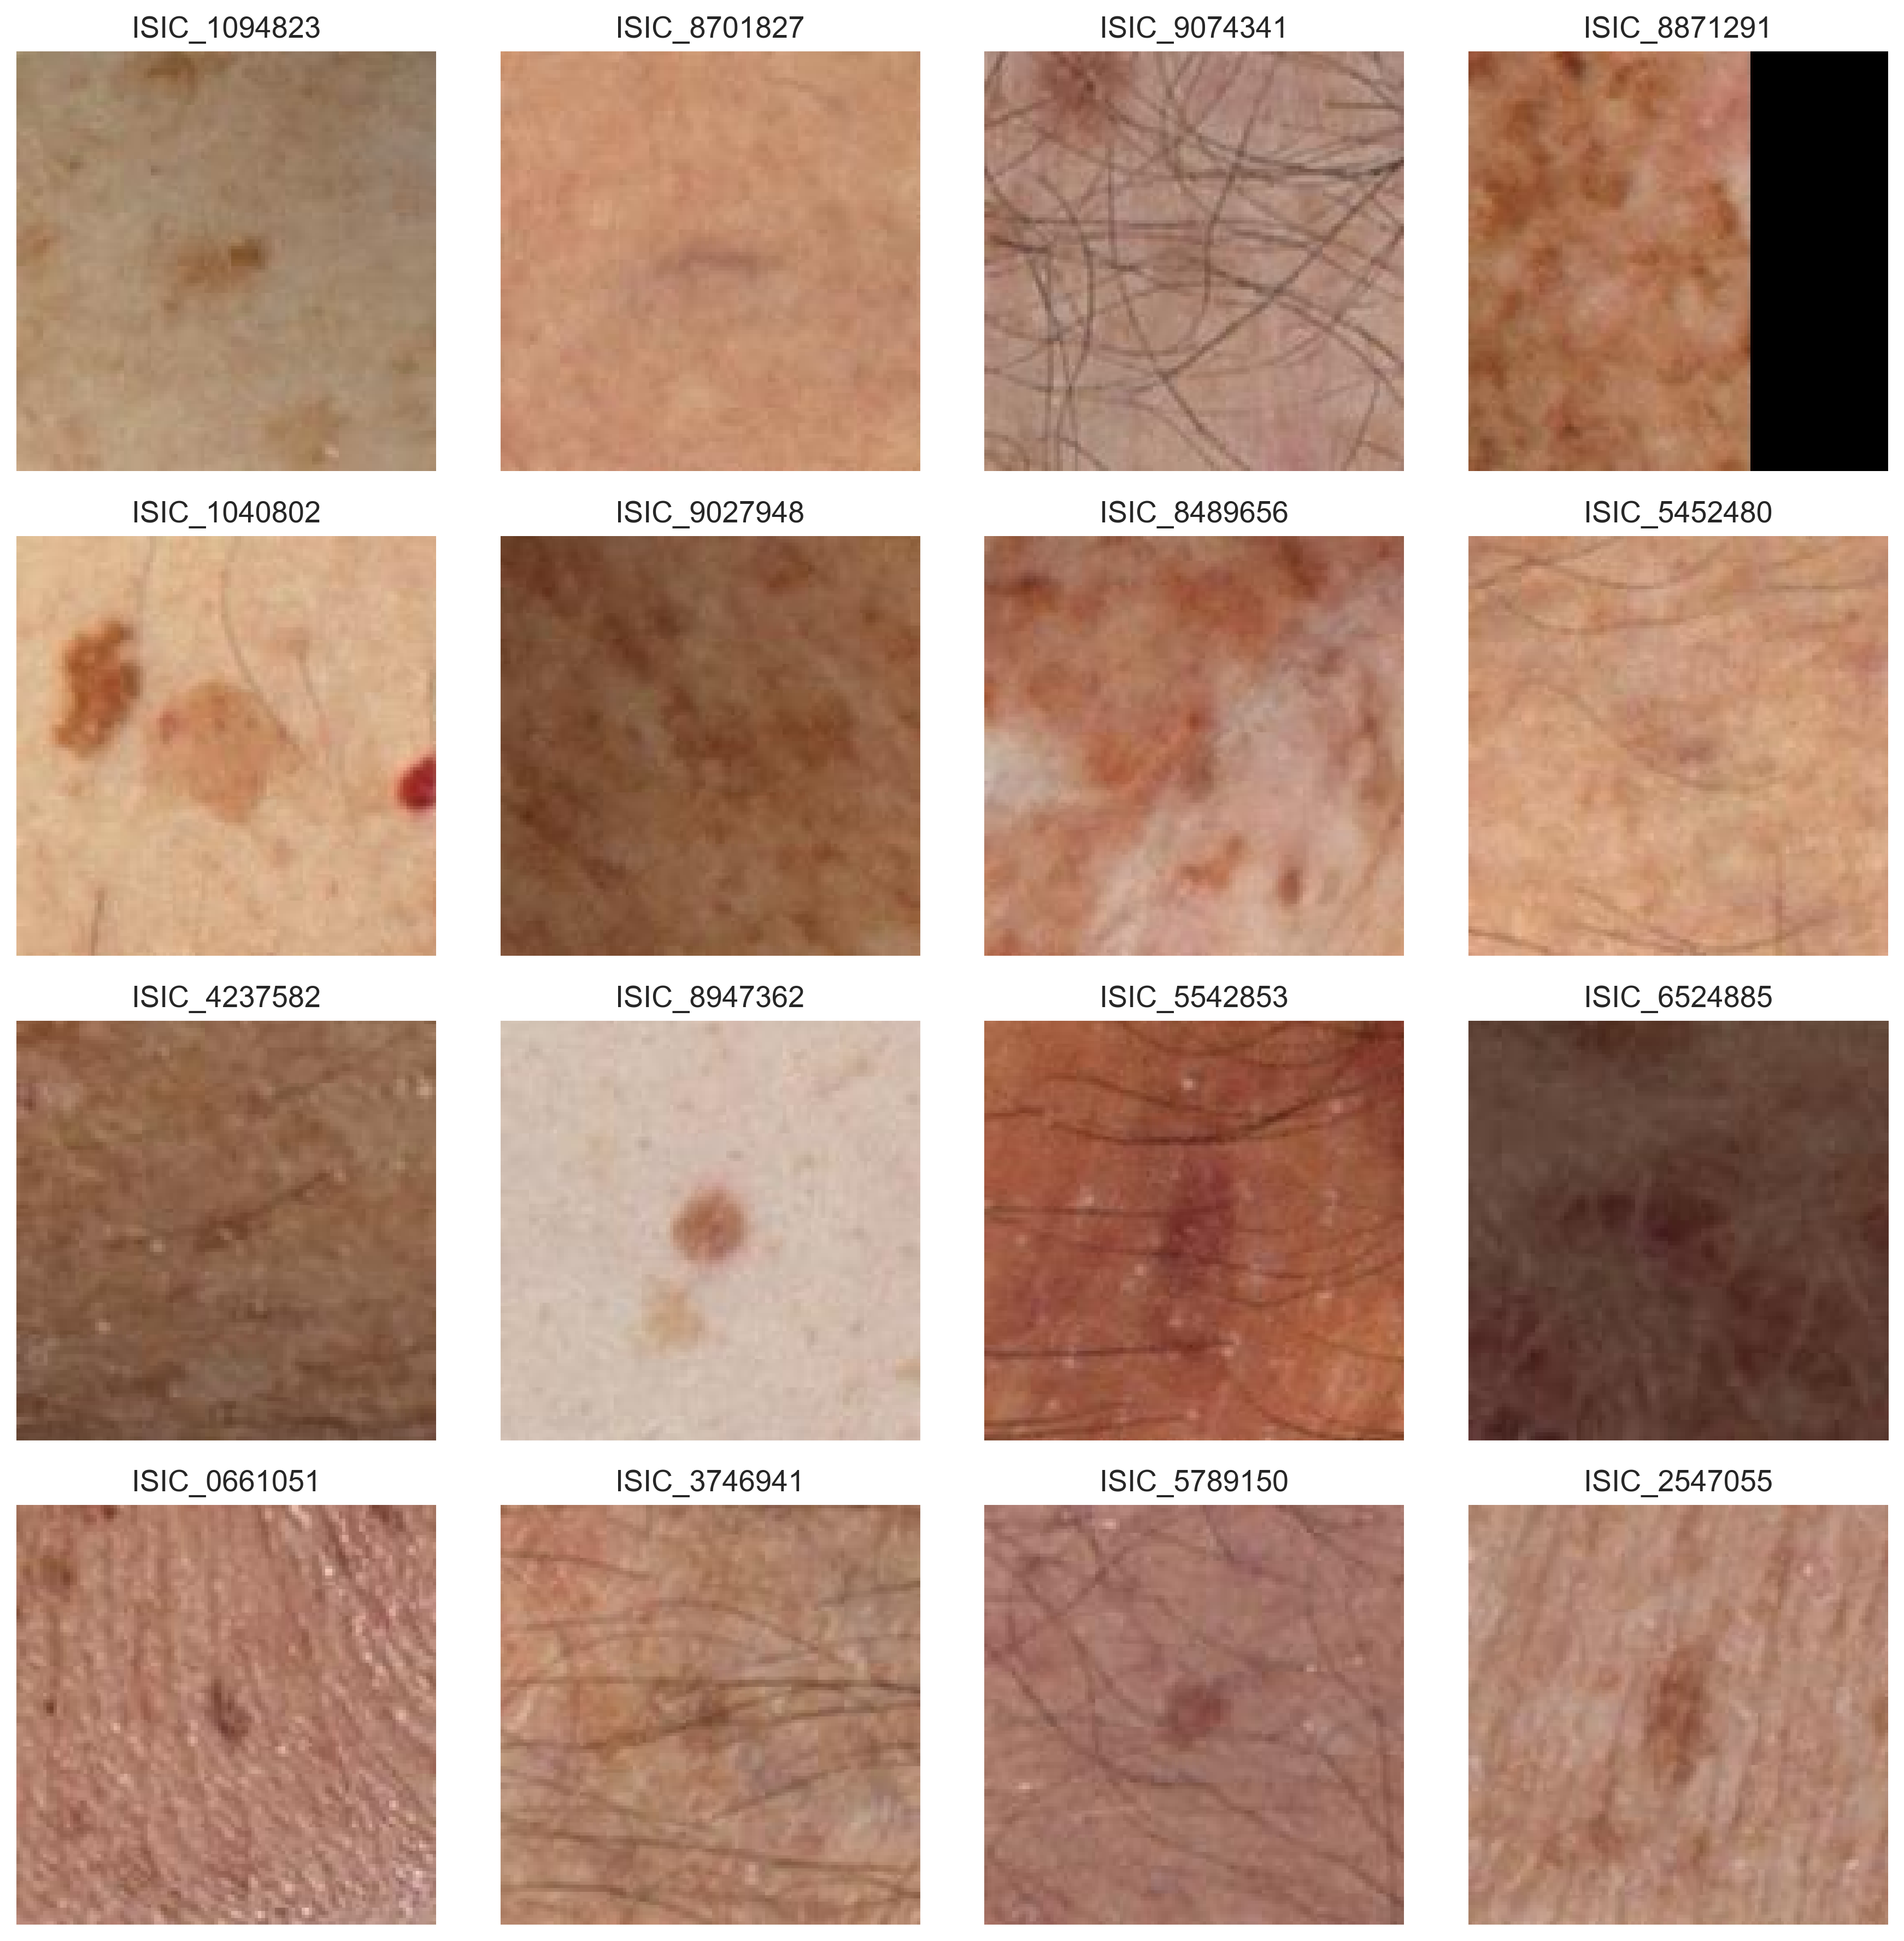

In [65]:
# Display sample images

sample_images = np.random.choice(image_files, 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, img_path in zip(axes.flatten(), sample_images):
    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Small Image Inspection

In [66]:
# Display the smallest images in the dataset

smallest_images = resolution_df.sort_values("width").head(20)

smallest_images.head()
# len(resolution_df)

,image_id,width,height,aspect_ratio
7543,ISIC_0259506,41,41,1.0
379346,ISIC_9458405,45,45,1.0
77129,ISIC_1981556,45,45,1.0
271835,ISIC_6808109,47,47,1.0
96012,ISIC_2450218,47,47,1.0


In [67]:
# Display the smallest images with width less than 100 pixels

threshold = 100

candidate_small_images = resolution_df[resolution_df["width"] < threshold]

candidate_small_images.shape

(6416, 4)

In [68]:
# Display the candidate small images

candidate_small_images.head()

,image_id,width,height,aspect_ratio
30,ISIC_0052259,99,99,1.0
61,ISIC_0073642,99,99,1.0
71,ISIC_0073877,87,87,1.0
84,ISIC_0074366,99,99,1.0
101,ISIC_0075770,93,93,1.0


In [69]:
# Display a random sample of the candidate small images

sample_small_images = candidate_small_images.sample(
    min(10, len(candidate_small_images)), random_state=42
)

sample_small_images

,image_id,width,height,aspect_ratio
310910,ISIC_7772673,93,93,1.0
328545,ISIC_8214302,99,99,1.0
67720,ISIC_1746653,97,97,1.0
80957,ISIC_2075873,99,99,1.0
310514,ISIC_7764238,87,87,1.0
304526,ISIC_7615368,71,71,1.0
390663,ISIC_9737769,87,87,1.0
291134,ISIC_7285531,97,97,1.0
329256,ISIC_8231833,95,95,1.0
155616,ISIC_3933768,97,97,1.0


# Resize Strategy Analysis

## Candidate Input Sizes

Several candidate input resolutions are evaluated in order to quantify the trade-off between image fidelity and computational requirements.

The selected resolutions cover lightweight, intermediate and high-resolution scenarios commonly used in deep learning pipelines.

The objective is not to determine the final input size immediately, but rather to assess the impact that each candidate resolution would have on the dataset.

* 96  → muy pequeño
* 128 → cercano a la mediana
* 160 → ampliación moderada
* 192 → ampliación alta
* 224 → estándar transfer learning

In [70]:
# Candidate image sizes for resizing during preprocessing based on the distribution of
# image widths and the presence of small images in the dataset. These sizes are commonly
# used in image classification tasks and can help ensure that the model receives input
# images of consistent dimensions while retaining important features.

candidate_sizes = [
    96,
    128,
    160,
    192,
    224,
]

candidate_sizes

[96, 128, 160, 192, 224]

## Resize Impact Analysis

For each candidate resolution, the number of images that would require upscaling, downscaling or no transformation is calculated.

This analysis helps quantify the amount of interpolation introduced by each candidate size.

In [71]:
# Analyze the impact of resizing all images to each candidate size on the dataset

summary = []

for size in candidate_sizes:
    n_upsampled = (resolution_df["width"] < size).sum()

    n_downsampled = (resolution_df["width"] > size).sum()

    n_same = (resolution_df["width"] == size).sum()

    summary.append(
        {
            "input_size": size,
            "upsampled_n": n_upsampled,
            "upsampled_pct": (n_upsampled / len(resolution_df) * 100),
            "downsampled_n": n_downsampled,
            "downsampled_pct": (n_downsampled / len(resolution_df) * 100),
            "same_size_n": n_same,
            "same_size_pct": (n_same / len(resolution_df) * 100),
        }
    )

resize_impact_df = pd.DataFrame(summary)

resize_impact_df

,input_size,upsampled_n,upsampled_pct,downsampled_n,downsampled_pct,same_size_n,same_size_pct
0,96,3547,0.884409,397512,99.115591,0,0.0
1,128,160794,40.092355,240265,59.907645,0,0.0
2,160,372461,92.869378,28598,7.130622,0,0.0
3,192,397561,99.127809,3498,0.872191,0,0.0
4,224,400766,99.926943,293,0.073057,0,0.0


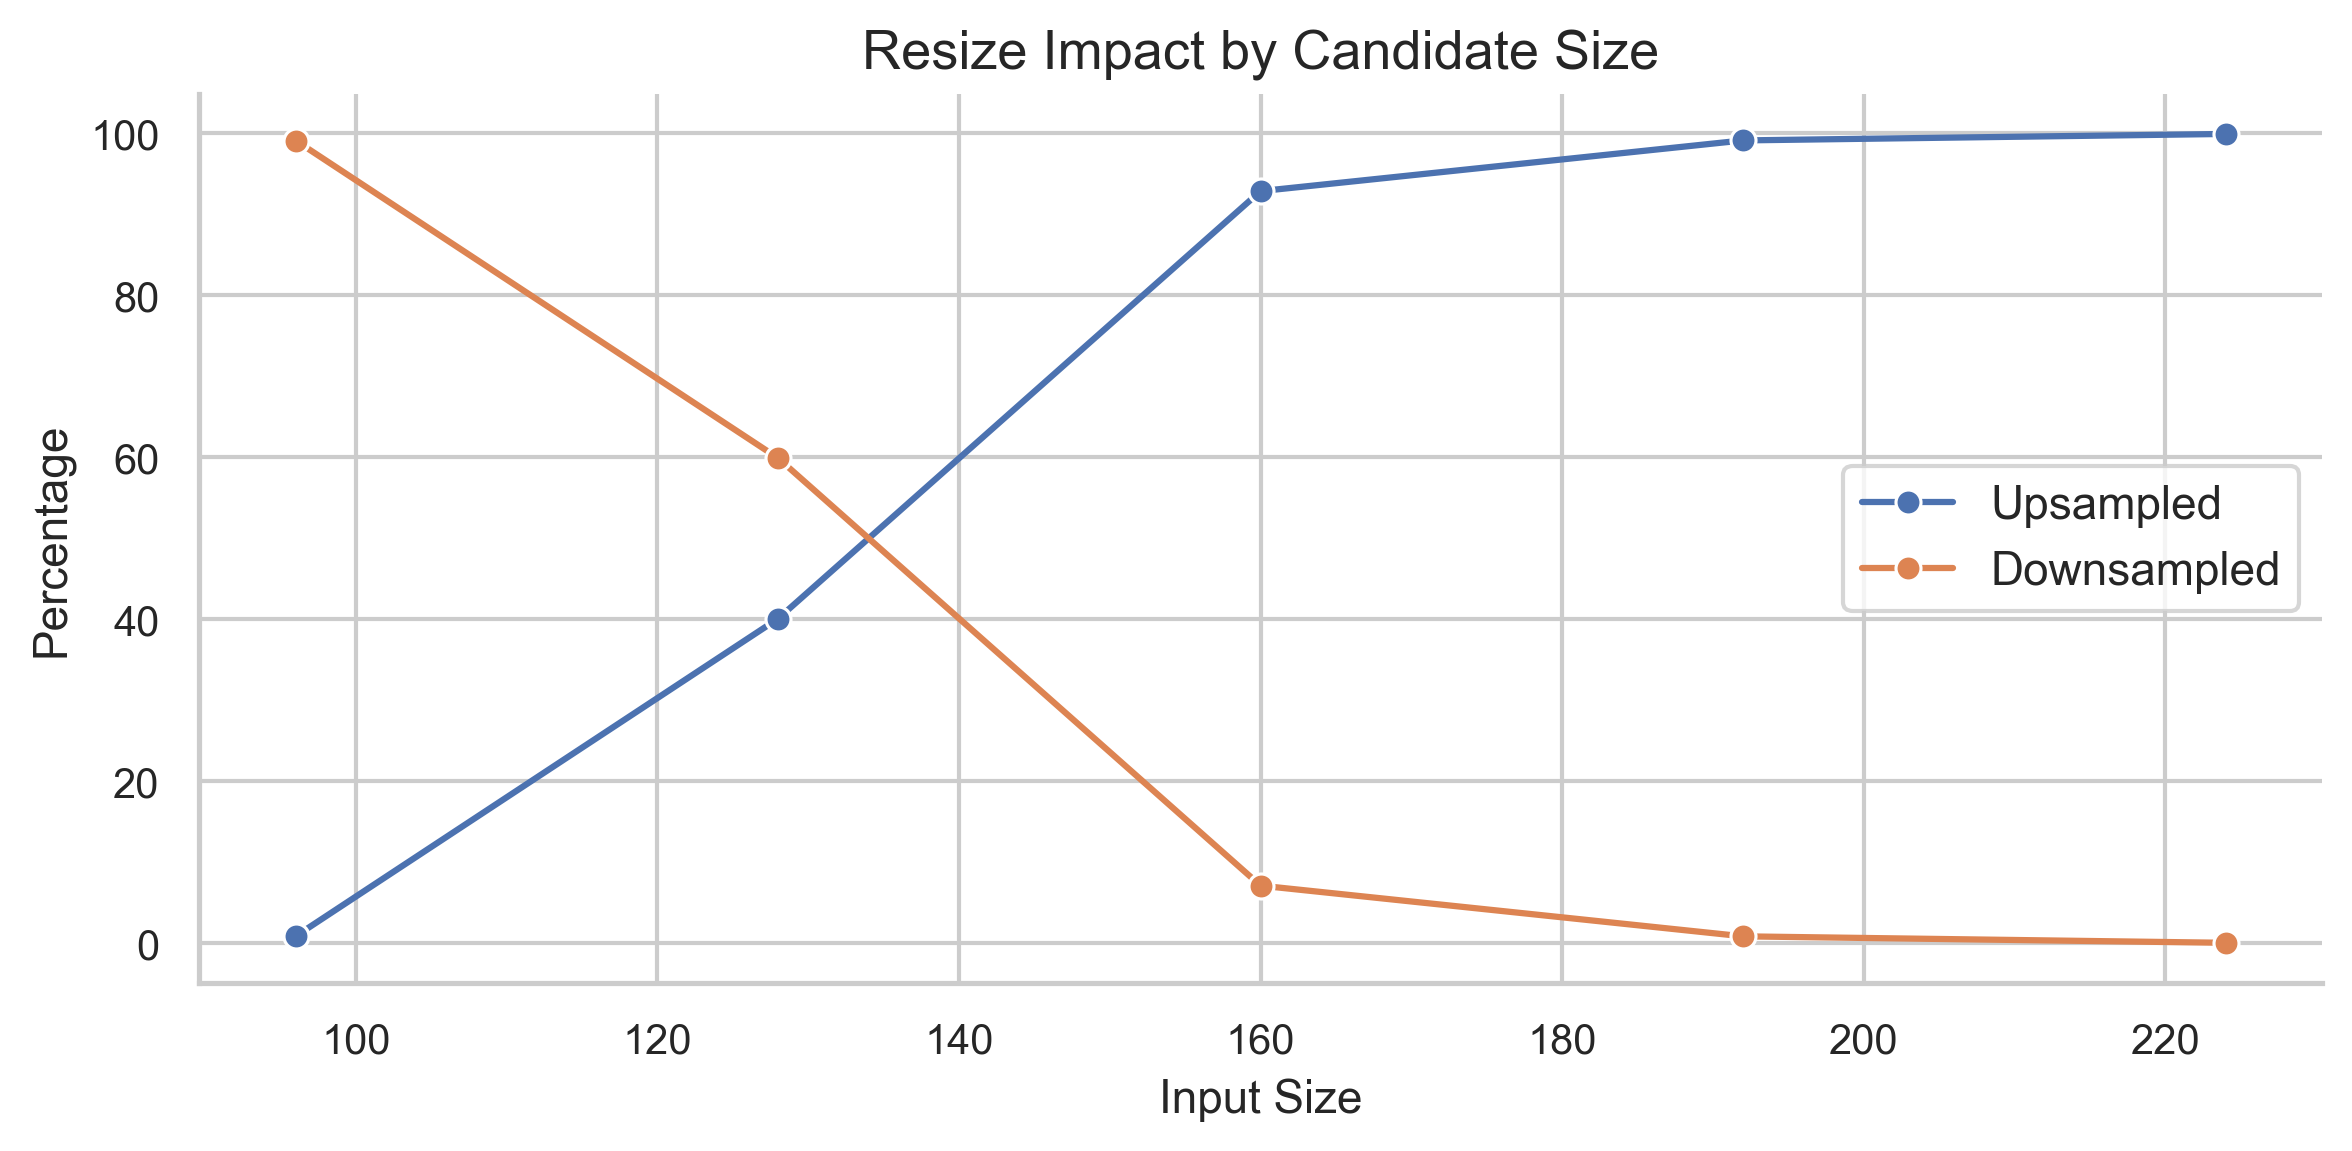

In [72]:
# Plot the impact of resizing on the dataset for each candidate size

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(
    data=resize_impact_df,
    x="input_size",
    y="upsampled_pct",
    marker="o",
    label="Upsampled",
)

sns.lineplot(
    data=resize_impact_df,
    x="input_size",
    y="downsampled_pct",
    marker="o",
    label="Downsampled",
)

clean_axis_labels(
    ax,
    xlabel="Input Size",
    ylabel="Percentage",
    title="Resize Impact by Candidate Size",
)

plt.tight_layout()
plt.show()

The candidate resolutions produce substantially different resizing behaviours.

A resolution of 96 pixels would require downsampling approximately 99.1% of all images, potentially discarding a significant amount of visual information.

Conversely, resolutions of 192 and 224 pixels would require upsampling more than 99% of the dataset, introducing substantial interpolation and increasing computational costs.

The 128-pixel candidate represents the most balanced scenario, requiring upsampling for 40.1% of images and downsampling for 59.9%.

This balance minimizes aggressive transformations while remaining close to the natural resolution distribution observed in the dataset.

## Scale Factor Analysis

The resize operation modifies the spatial resolution of every image.

The scale factor distribution is evaluated to quantify how aggressively images would be enlarged or reduced under each candidate input size.

In [73]:
# Analyze the distribution of scale factors for resizing to each candidate size

scale_summary = []

for size in candidate_sizes:
    scale_factor = size / resolution_df["width"]

    scale_summary.append(
        {
            "input_size": size,
            "mean_scale_factor": scale_factor.mean(),
            "median_scale_factor": scale_factor.median(),
            "p25_scale_factor": scale_factor.quantile(0.25),
            "p75_scale_factor": scale_factor.quantile(0.75),
            "min_scale_factor": scale_factor.min(),
            "max_scale_factor": scale_factor.max(),
        }
    )

scale_factor_df = pd.DataFrame(scale_summary)

scale_factor_df

,input_size,mean_scale_factor,median_scale_factor,p25_scale_factor,p75_scale_factor,min_scale_factor,max_scale_factor
0,96,0.733719,0.732824,0.671329,0.793388,0.356877,2.341463
1,128,0.978292,0.977099,0.895105,1.057851,0.475836,3.121951
2,160,1.222866,1.221374,1.118881,1.322314,0.594796,3.902439
3,192,1.467439,1.465649,1.342657,1.586777,0.713755,4.682927
4,224,1.712012,1.709924,1.566434,1.851240,0.832714,5.463415


<Axes: xlabel='input_size', ylabel='median_scale_factor'>

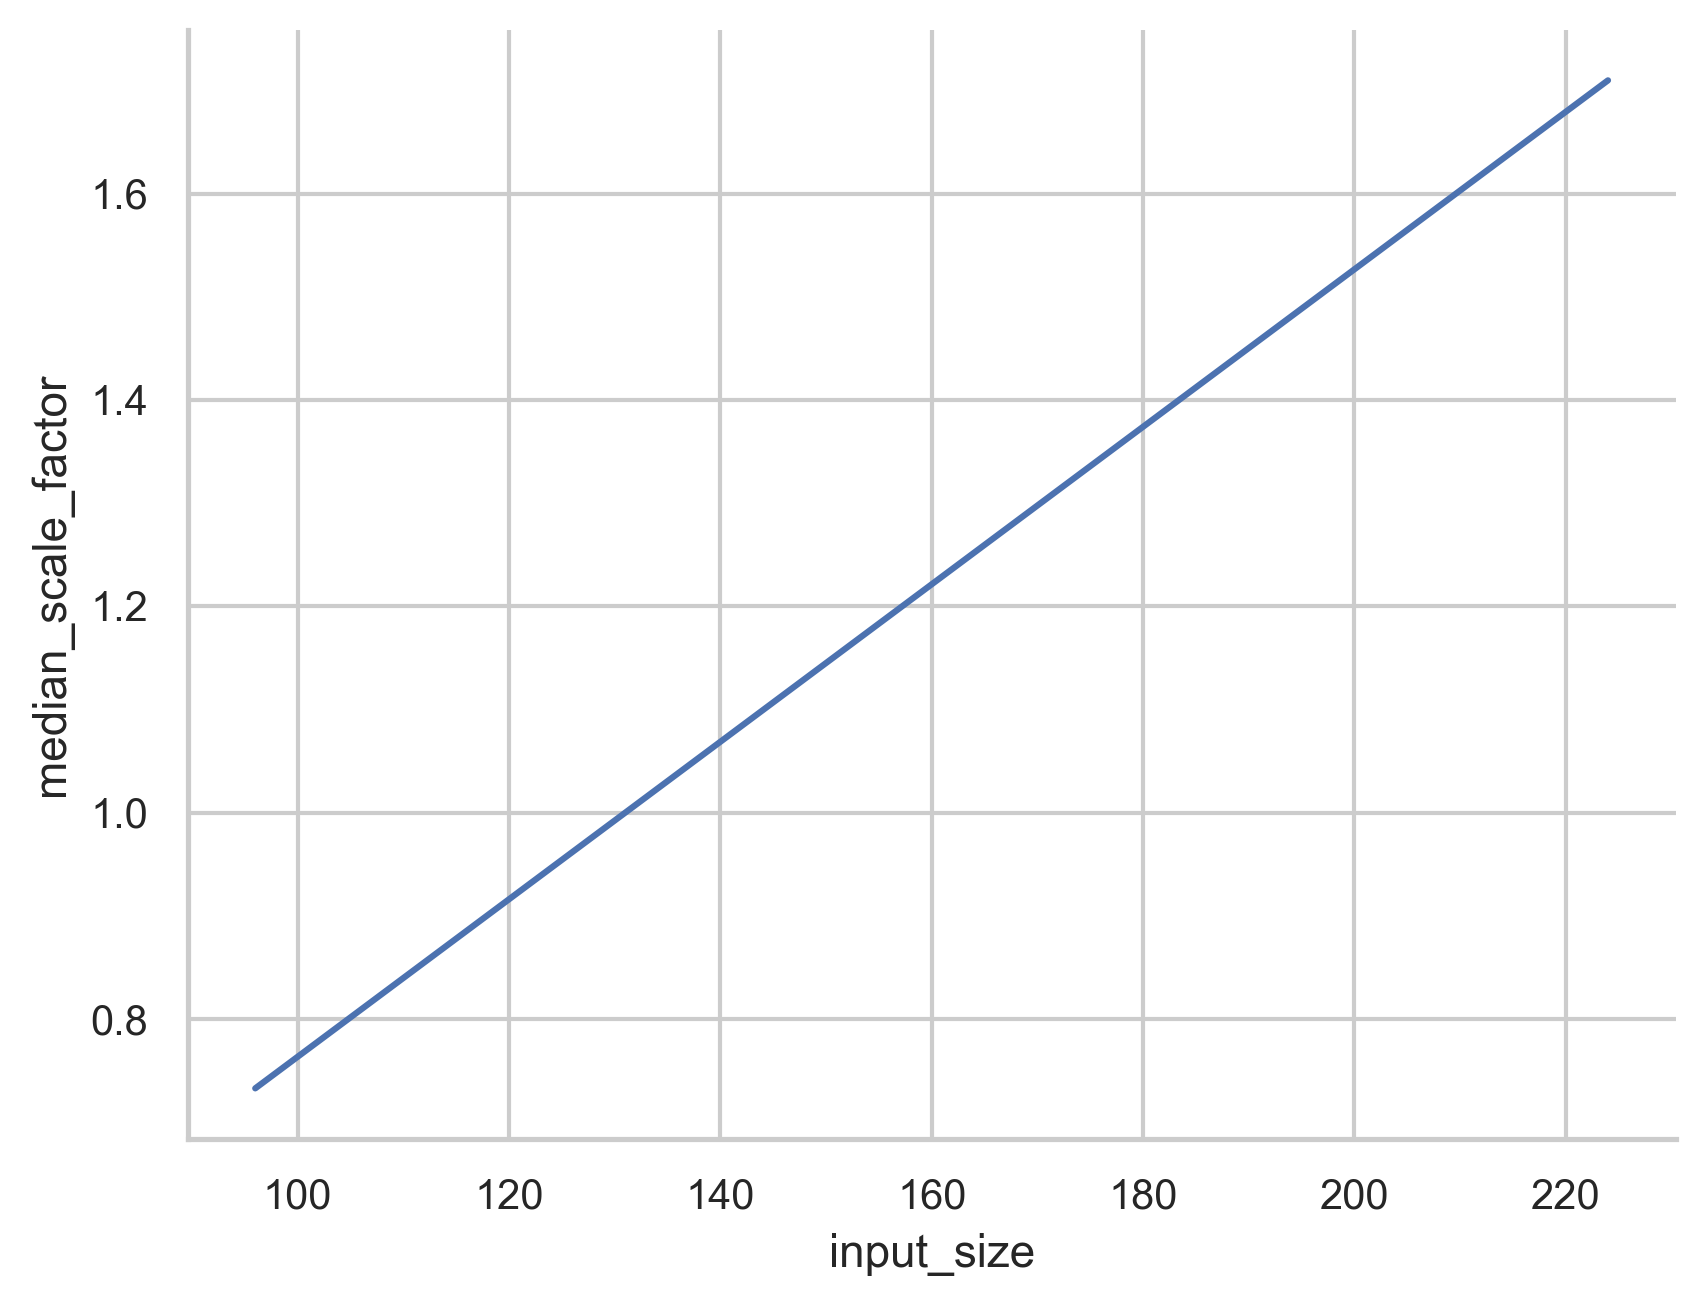

In [74]:
# Plot the median scale factor for each candidate input size to visualize
# how much resizing would be required on average for each size

sns.lineplot(data=scale_factor_df, x="input_size", y="median_scale_factor")

The scale factor analysis confirms that candidate sizes above the native dataset resolution introduce increasingly aggressive interpolation.

For the 128-pixel candidate, the median scale factor is 0.98, indicating that most images require only minimal resizing.

In contrast, resolutions of 160, 192 and 224 pixels produce median scale factors above 1.2, 1.46 and 1.71 respectively, meaning that the majority of images must be enlarged.

The maximum scale factor reaches 5.46 for the 224-pixel candidate, highlighting the presence of extreme upsampling for low-resolution images.

Overall, 128 pixels preserves the original spatial characteristics of the dataset more effectively than the larger alternatives.

## Memory Footprint Analysis

The computational cost associated with each candidate resolution is estimated.

The objective is to evaluate the trade-off between image detail and memory consumption before selecting a final preprocessing strategy.

In [75]:
# Estimate memory requirements for resizing all images to each candidate size

memory_summary = []

n_images = len(image_files)

channels = 3

for size in candidate_sizes:
    n_pixels = n_images * size * size * channels

    uint8_gb = n_pixels * 1 / (1024**3)

    float32_gb = n_pixels * 4 / (1024**3)

    memory_summary.append(
        {
            "input_size": size,
            "pixels_per_image": size * size * channels,
            "uint8_size_gb": uint8_gb,
            "float32_size_gb": float32_gb,
        }
    )

memory_df = pd.DataFrame(memory_summary)

memory_df

,input_size,pixels_per_image,uint8_size_gb,float32_size_gb
0,96,27648,10.326951,41.307804
1,128,49152,18.359024,73.436096
2,160,76800,28.685975,114.743900
3,192,110592,41.307804,165.231216
4,224,150528,56.224511,224.898045


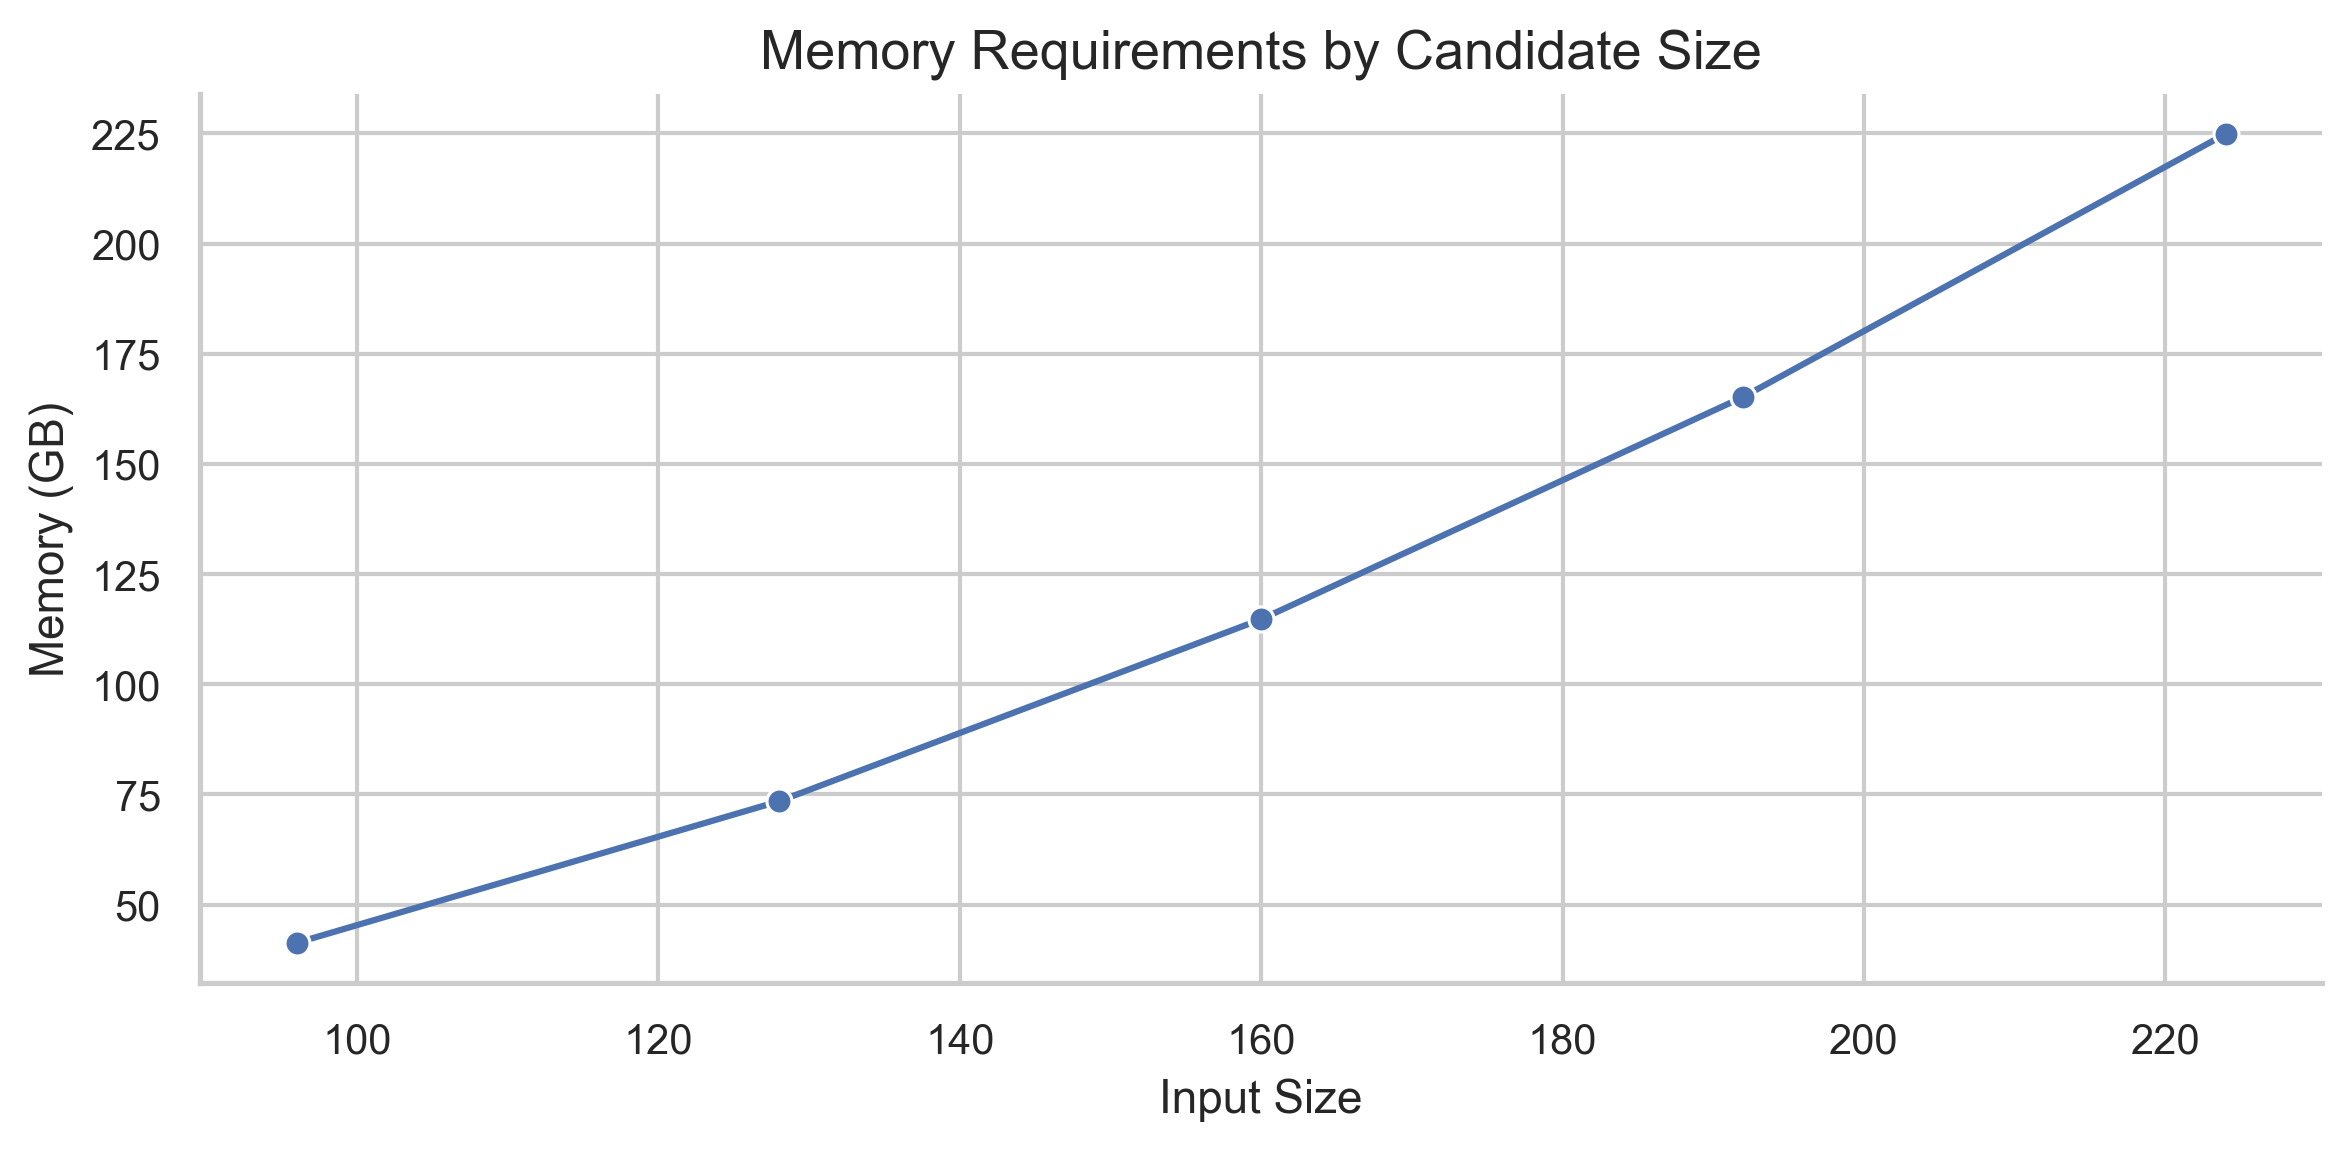

In [76]:
# Plot the memory requirements for resizing all images to each candidate
# size in float32 format, which is commonly used for model input tensors

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(
    data=memory_df,
    x="input_size",
    y="float32_size_gb",
    marker="o",
)

clean_axis_labels(
    ax,
    xlabel="Input Size",
    ylabel="Memory (GB)",
    title="Memory Requirements by Candidate Size",
)

plt.tight_layout()
plt.show()

Memory requirements increase quadratically with image resolution.

While a 128-pixel representation would require approximately 18.4 GB in uint8 format and 73.4 GB in float32 format, a 224-pixel representation would increase memory requirements to approximately 56.2 GB and 224.9 GB respectively.

Therefore, larger resolutions impose substantially higher storage and computational costs without necessarily providing additional clinical information.

The 128-pixel candidate offers the most favourable balance between dataset fidelity and computational efficiency.

## Visual Comparison of Candidate Resolutions

Statistical metrics provide an estimate of the resizing impact, but they do not reveal how image appearance changes after interpolation.

To complement the quantitative analysis, representative images with low, median and high native resolutions are resized using each candidate input size.

The objective is to visually assess the effect of downsampling and upsampling before selecting a final preprocessing strategy.

In [77]:
# Identify specific images that are small, median, and large based on width

small_image_id = resolution_df.sort_values("width").iloc[0]["image_id"]

median_idx = (resolution_df["width"] - resolution_df["width"].median()).abs().idxmin()

median_image_id = resolution_df.loc[median_idx, "image_id"]

large_image_id = resolution_df.sort_values("width").iloc[-1]["image_id"]

print("Small:", small_image_id)
print("Median:", median_image_id)
print("Large:", large_image_id)

Small: ISIC_0259506
Median: ISIC_0052231
Large: ISIC_8361296


In [78]:
# Display the selected images

selected_images_df = resolution_df[
    resolution_df["image_id"].isin(
        [
            small_image_id,
            median_image_id,
            large_image_id,
        ]
    )
]

selected_images_df

,image_id,width,height,aspect_ratio
28,ISIC_0052231,131,131,1.0
7543,ISIC_0259506,41,41,1.0
334470,ISIC_8361296,269,269,1.0


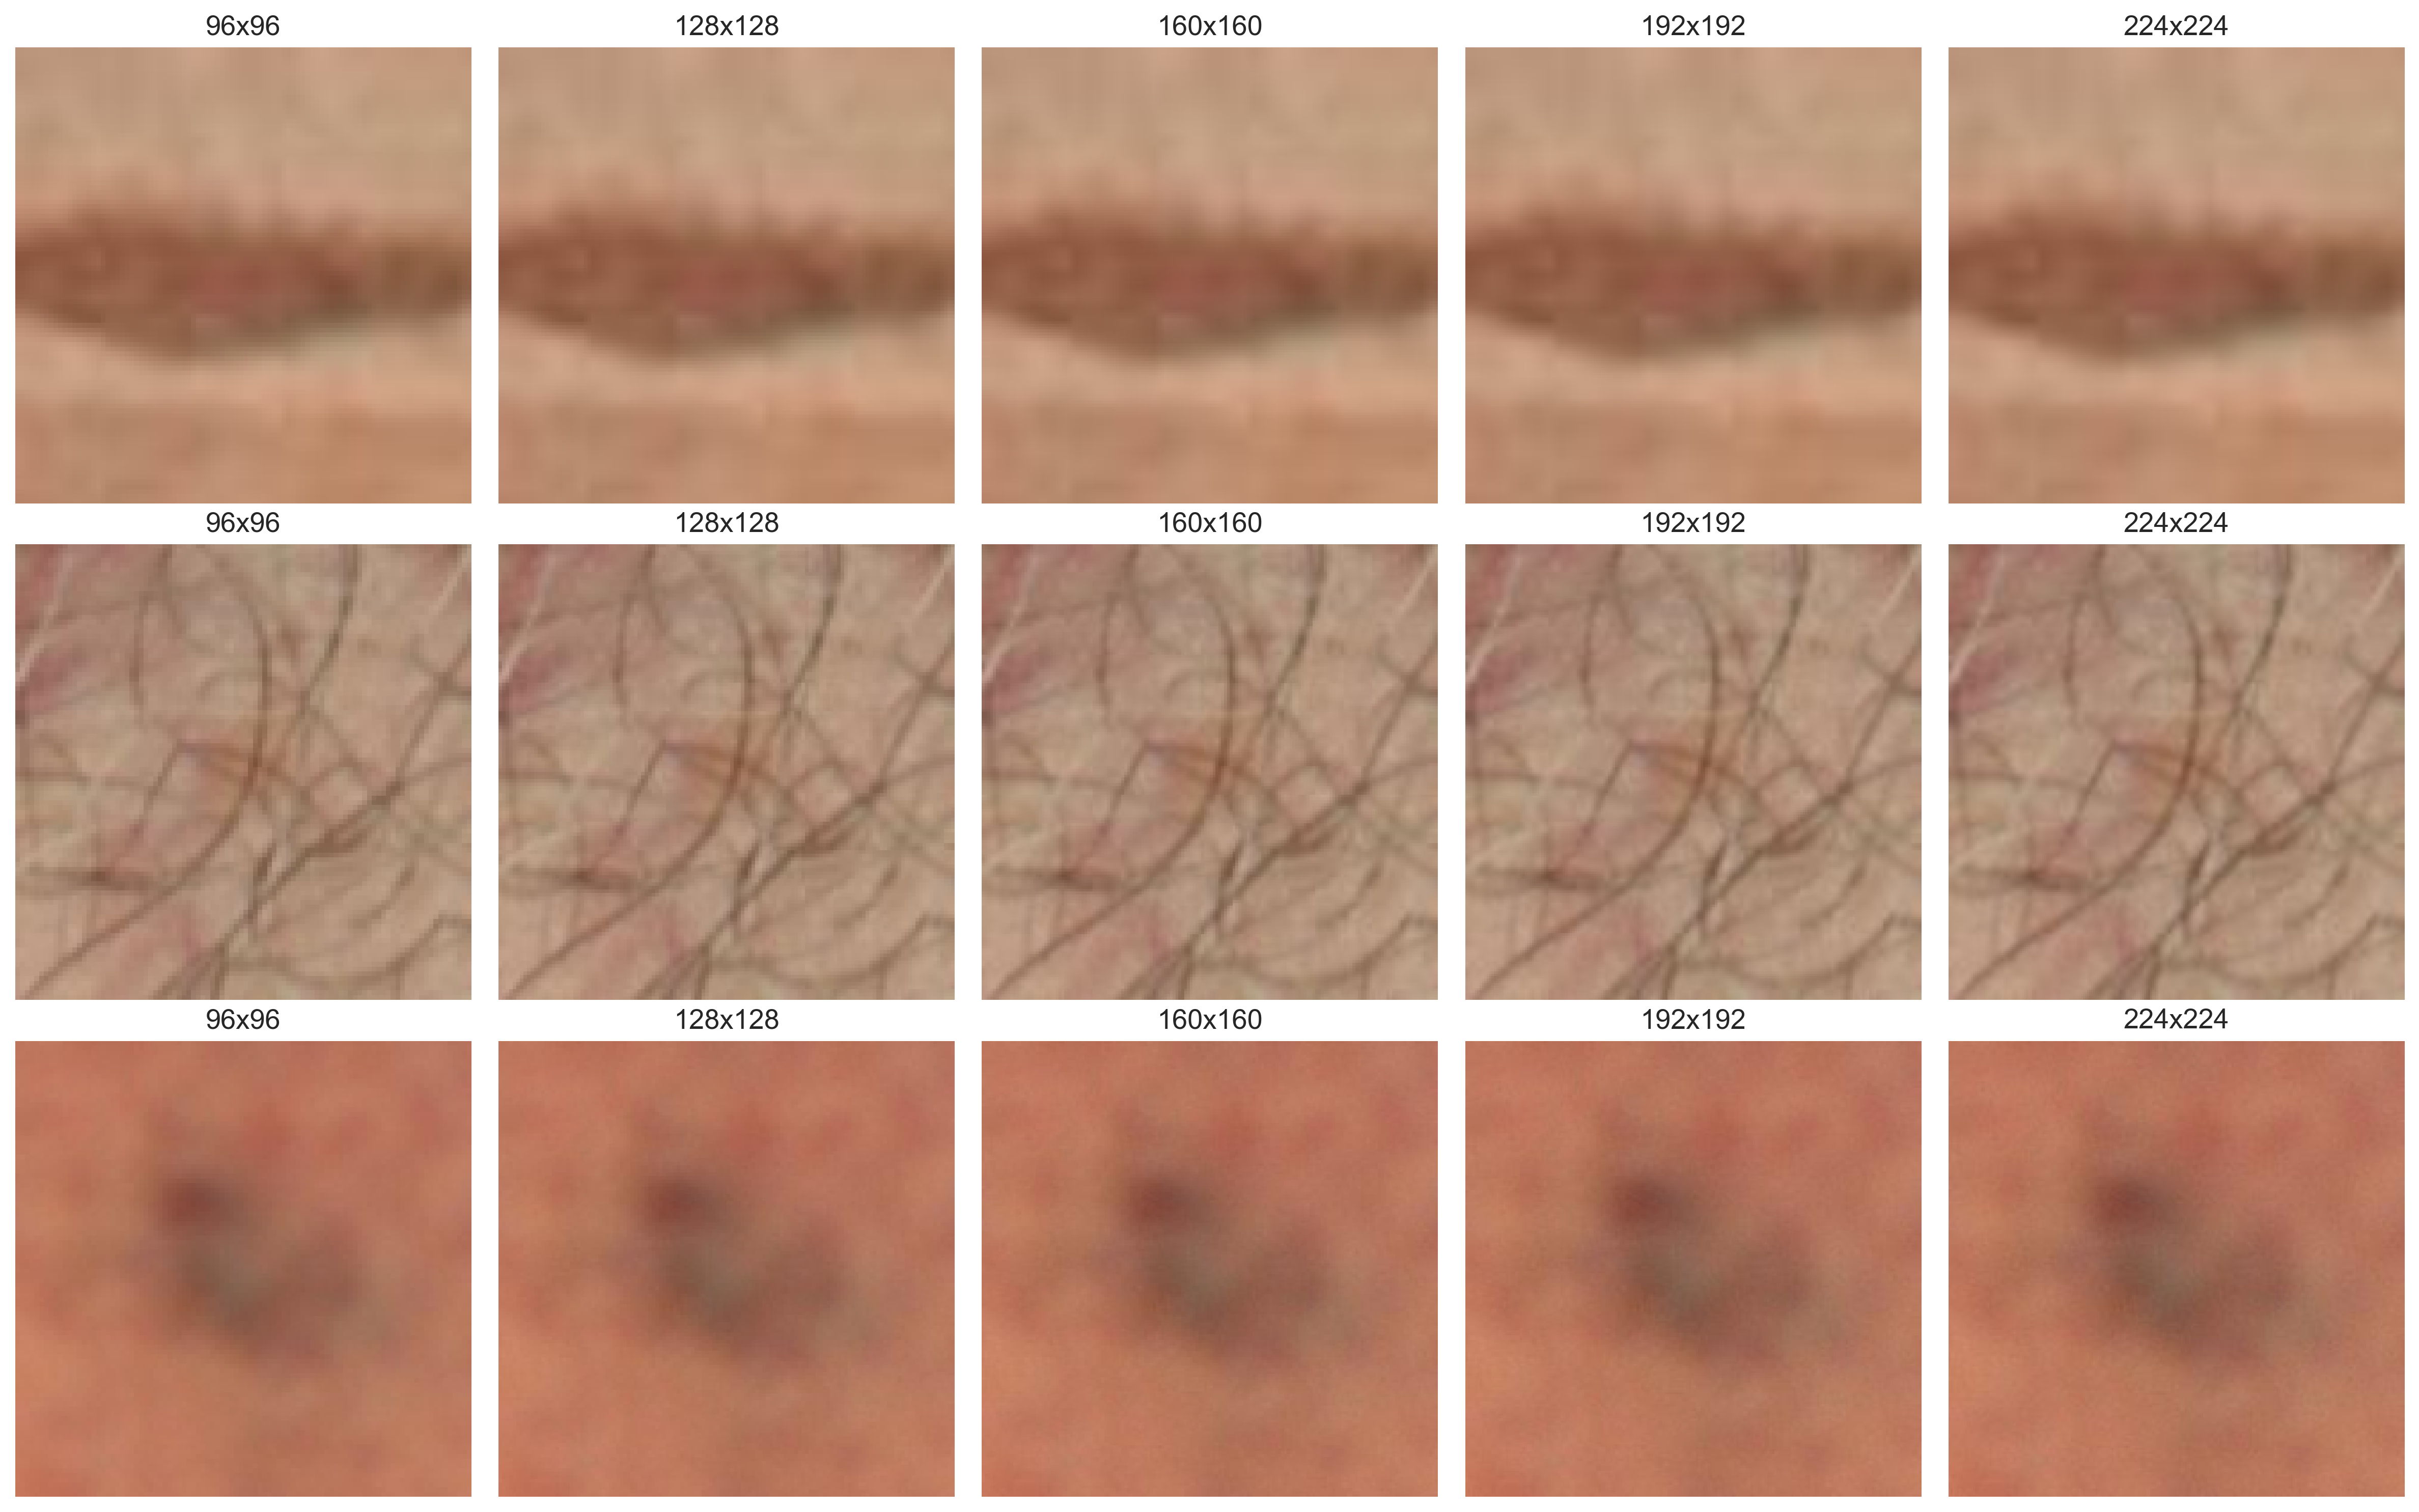

In [79]:
# Display the selected images at different candidate sizes to visualize the impact of resizing

candidate_sizes = [
    96,
    128,
    160,
    192,
    224,
]

selected_images = {
    "Small": small_image_id,
    "Median": median_image_id,
    "Large": large_image_id,
}

fig, axes = plt.subplots(len(selected_images), len(candidate_sizes), figsize=(16, 10))

for row, (label, img_id) in enumerate(selected_images.items()):
    img_path = IMAGE_DIR / f"{img_id}.jpg"

    original = Image.open(img_path)

    for col, size in enumerate(candidate_sizes):
        resized = original.resize((size, size), Image.BILINEAR)

        axes[row, col].imshow(resized)

        axes[row, col].set_title(f"{size}x{size}")

        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=12)

plt.tight_layout()
plt.show()

* For extremely low-resolution images, visual differences between candidate resizing strategies remain limited.

Upsampling beyond 160 pixels does not appear to introduce additional clinically meaningful information and mainly increases image dimensions through interpolation.

* For images close to the median dataset resolution, visual appearance remains highly stable across all evaluated candidate sizes.

This suggests that increasing the target resolution above the native image dimensions provides limited additional information.

* Increasing image size through interpolation does not recover information that is absent in the original image.

Consequently, larger target resolutions may increase computational costs without improving the visual quality of low-detail lesions.

# Storage Analysis

## Dataset Disk Usage

In [80]:
# Calculate total size of images in GB

total_bytes = sum(os.path.getsize(file) for file in image_files)

total_gb = total_bytes / (1024**3)

print(f"{total_gb:.2f} GB")

1.06 GB


In [81]:
# Calculate average image size in KB

avg_kb = total_bytes / len(image_files) / 1024

print(f"Average image size: {avg_kb:.2f} KB")

Average image size: 2.77 KB


The complete image repository occupies approximately 1.06 GB on disk.

Considering that the dataset contains 401,059 RGB images, this storage footprint is relatively small and consistent with the low native image resolutions observed during the audit.

The compact size of the repository facilitates experimentation and reduces storage requirements during preprocessing and model development.

# Findings and Conclusions

## 1. Dataset Integrity

The image repository contains exactly **401,059 images**, matching the number of records available in the metadata files.

- Metadata records: 401,059
- Physical image files: 401,059
- Missing images: 0
- Extra images: 0

This confirms a perfect one-to-one correspondence between metadata and image files and ensures that no observations are lost during subsequent preprocessing stages.

---

## 2. Image Quality

The image audit confirms a highly homogeneous image repository.

Key findings:

- All images are stored in JPEG format.
- All images use the RGB color mode.
- No corrupted images were detected.

As a result, no image-cleaning, channel-conversion or format-standardization steps are required before preprocessing.

---

## 3. Resolution Analysis

Image dimensions are highly consistent across the dataset.

Summary statistics:

- Mean resolution: 133 × 133 pixels
- Median resolution: 131 × 131 pixels
- 25th percentile: 121 × 121 pixels
- 75th percentile: 143 × 143 pixels
- Minimum resolution: 41 × 41 pixels
- Maximum resolution: 269 × 269 pixels

All images are square:

- Aspect ratio = 1.0

The resolution distribution is strongly concentrated around the median range, indicating a highly standardized acquisition process.

Outlier analysis identified a limited number of unusually small or large images; however, these observations represent a small proportion of the dataset and do not currently justify exclusion.

---

## 4. Candidate Input Size Evaluation

Several candidate input resolutions were evaluated:

- 96 × 96
- 128 × 128
- 160 × 160
- 192 × 192
- 224 × 224

The evaluation considered:

- Resize impact
- Scale-factor distribution
- Memory requirements
- Visual inspection of resized images

The analysis showed that larger candidate sizes require substantial upsampling of the original images.

For example:

- 160 × 160 requires upsampling approximately 92.9% of the dataset.
- 192 × 192 requires upsampling approximately 99.1% of the dataset.
- 224 × 224 requires upsampling approximately 99.9% of the dataset.

Visual inspection further demonstrated that aggressive upsampling does not recover clinically meaningful information when it is not present in the original image.

---

## 5. Recommended Preprocessing Strategy

Among all evaluated candidates, **128 × 128 pixels** provides the most balanced preprocessing strategy.

Key advantages include:

- Closest candidate to the native image resolution distribution.
- Minimal resizing relative to the original images.
- Median scale factor close to 1.0.
- Reduced interpolation requirements.
- Lower memory footprint compared with larger alternatives.

Additionally, visual inspection revealed no substantial gain in image detail when increasing the target resolution beyond 128 pixels.

Consequently, 128 × 128 was selected as the baseline preprocessing resolution for the initial stages of the project.

---

## 6. Next Steps

The results of this image audit will be used to guide the image preprocessing pipeline.

The next stage will focus on:

- Integrating image-level information with patient-level metadata.
- Incorporating diagnostic labels generated during metadata preprocessing.
- Defining the final image transformation pipeline.
- Generating the processed dataset required for model development.

At this stage, no images are removed from the dataset. Any future exclusion criteria will require additional justification based on both image characteristics and diagnostic metadata.

No evidence was found to support image exclusion based solely on image resolution.

Therefore, all images are retained at this stage pending integration with diagnostic metadata and patient-level information.